In [8]:
import matplotlib.pyplot as plt
import numpy as np
import math as maths
import pandas as pd
import matplotlib as mpl


sat_data = np.load("data/ireland_clouds_20240101_20250101.npz")
print(sat_data.files)

['times', 'cloud_mask', 'cth_km', 'lat', 'lon']


# Visualise a subset of the satellite frames

Pick a time window and a step, then look at the cloud maps and how cloud cover changes hour to hour.

In [9]:
cloud_mask = sat_data["cloud_mask"]   # (hours, 90, 120) 0 clear sea, 1 clear land, 2 cloud, 3 no data
cth_km = sat_data["cth_km"]           # (hours, 90, 120) cloud top height in km
sat_times = sat_data["times"]
lat, lon = sat_data["lat"], sat_data["lon"]

# the subset to look at -- change these
start, end = np.datetime64("2024-06-15T00"), np.datetime64("2024-06-16T00")
step = 3   # hours between plotted frames

idx = np.where((sat_times >= start) & (sat_times < end))[0]
print(f"{len(idx)} hours in subset, plotting every {step}h -> {len(idx[::step])} frames")

24 hours in subset, plotting every 3h -> 8 frames


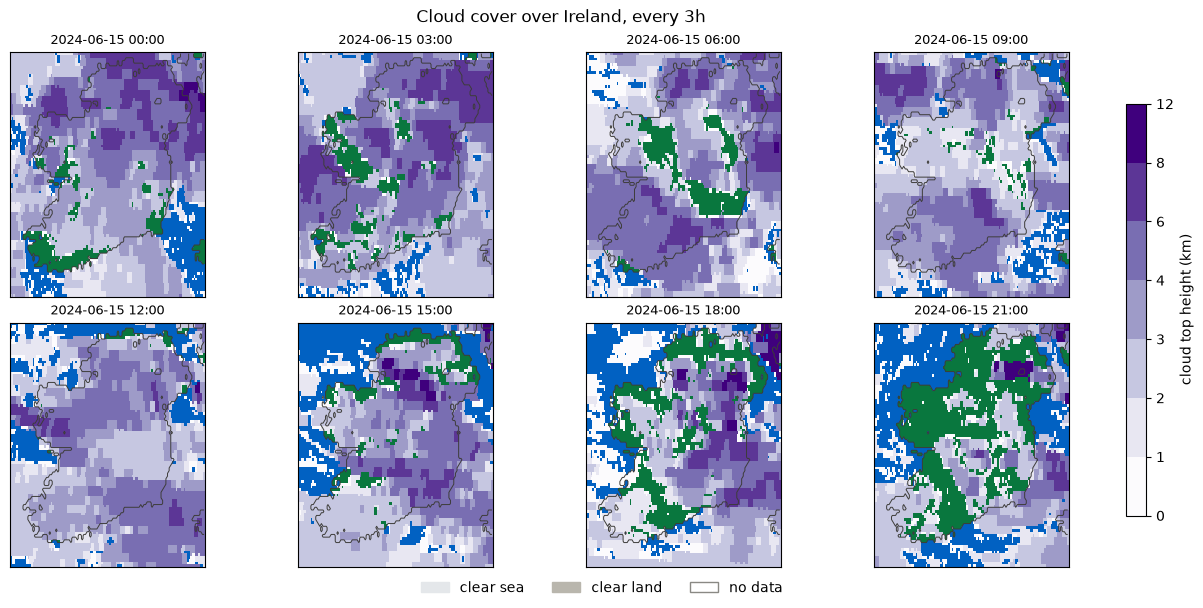

In [10]:
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

# clear pixels are background (two greys), clouds get a one-hue blue ramp by top height
bg_cmap = ListedColormap(["#0161c2", "#09773eff", "#ffffff", "#ffffff"])   # sea, land, (cloud drawn on top), no data
height_cmap = mpl.colormaps["Purples"]
height_bounds = [0, 1, 2, 3, 4, 6, 8, 12]
height_norm = BoundaryNorm(height_bounds, height_cmap.N)

# land/sea never changes: a pixel is land if it was ever seen as clear land -> draw it as a coastline
land = (cloud_mask == 1).any(axis=0).astype(float)

def draw_coast(ax):
    ax.contour(lon, lat, land, levels=[0.5], colors="#3d3c39", linewidths=0.7)

def plot_frame(ax, t):
    ax.pcolormesh(lon, lat, cloud_mask[t], cmap=bg_cmap, vmin=-0.5, vmax=3.5, shading="nearest")
    h = np.ma.masked_where(cloud_mask[t] != 2, cth_km[t].astype(np.float32))
    im = ax.pcolormesh(lon, lat, h, cmap=height_cmap, norm=height_norm, shading="nearest")
    draw_coast(ax)
    ax.set_aspect(1 / np.cos(np.deg2rad(lat.mean())))   # degrees -> roughly true shape at Irish latitudes
    ax.set_title(str(sat_times[t].astype("datetime64[m]")).replace("T", " "), fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    if (cloud_mask[t] == 3).all():
        ax.text(0.5, 0.5, "no data", transform=ax.transAxes, ha="center", va="center", color="#52514e")
    return im

frames_to_plot = idx[::step]
ncols = 4
nrows = maths.ceil(len(frames_to_plot) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3.0 * nrows), constrained_layout=True)
axes = np.atleast_1d(axes).ravel()
for ax, t in zip(axes, frames_to_plot):
    im = plot_frame(ax, t)
for ax in axes[len(frames_to_plot):]:
    ax.axis("off")

fig.colorbar(im, ax=axes.tolist(), label="cloud top height (km)", shrink=0.8)
fig.legend(handles=[Patch(color="#e4e7ea", label="clear sea"), Patch(color="#b9b6ad", label="clear land"),
                    Patch(facecolor="#ffffff", edgecolor="#8a8984", label="no data")],
           loc="outside lower center", ncol=3, frameon=False)
fig.suptitle(f"Cloud cover over Ireland, every {step}h")
plt.show()